In [ ]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import sys
!{sys.executable} -m ensurepip
!{sys.executable} -m pip install openpyxl

Looking in links: /var/folders/h0/_1b5f8v5625c14tshm3876lm0000gn/T/tmpotr3sxmm
Processing /var/folders/h0/_1b5f8v5625c14tshm3876lm0000gn/T/tmpotr3sxmm/pip-25.0.1-py3-none-any.whl
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [15]:
import pandas as pd


# Load both Excel files
file_2024 = '/Users/kevinkim/projects/sales_forecasting/sales_2024.xlsx'
file_2025 = '/Users/kevinkim/projects/sales_forecasting/sales_2025.xlsx'


# Read all sheets from both files
sheets_2024 = pd.read_excel(file_2024, sheet_name=None)
sheets_2025 = pd.read_excel(file_2025, sheet_name=None)

# Combine all sheets into one dataframe
df = pd.concat(list(sheets_2024.values()) + list(sheets_2025.values()))

# Reset index and sort by date
df = df.sort_values('Date').reset_index(drop=True)

print(df.head(20))
print(df.shape)

         Date        Total
0  2024-01-01  1432.665484
1  2024-01-02  2242.965484
2  2024-01-03  2438.645484
3  2024-01-04  1926.895484
4  2024-01-05  2126.815484
5  2024-01-06  3011.195484
6  2024-01-07  2877.445484
7  2024-01-08  1813.915484
8  2024-01-09  1424.705484
9  2024-01-10  1449.875484
10 2024-01-11  1511.645484
11 2024-01-12  2086.245484
12 2024-01-13  3379.845484
13 2024-01-14  2596.785484
14 2024-01-15  2120.665484
15 2024-01-16  1226.795484
16 2024-01-17  1100.745484
17 2024-01-18  1582.105484
18 2024-01-19  1974.945484
19 2024-01-20  3580.075484
(731, 2)


In [16]:
!{sys.executable} -m pip install prophet

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 25.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 100.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 88.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [19]:
from prophet import Prophet

# Prophet requires columns to be named 'ds' and 'y'
df_prophet = df.rename(columns={'Date': 'ds', 'Total': 'y'})

print(df_prophet.head())

          ds            y
0 2024-01-01  1432.665484
1 2024-01-02  2242.965484
2 2024-01-03  2438.645484
3 2024-01-04  1926.895484
4 2024-01-05  2126.815484


In [20]:
# Build and train the model
model = Prophet()
model.fit(df_prophet)

17:17:15 - cmdstanpy - INFO - Chain [1] start processing
17:17:16 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# Create future dates to forecast (90 days into the future)
future = model.make_future_dataframe(periods=90)

# Generate the forecast
forecast = model.predict(future)

# Show the key columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

            ds         yhat   yhat_lower   yhat_upper
811 2026-03-22  2564.127197  1944.644541  3175.269205
812 2026-03-23  1380.003842   758.153262  2016.823517
813 2026-03-24  1205.615440   550.438110  1813.532018
814 2026-03-25  1218.911144   598.539268  1833.193227
815 2026-03-26  1282.160952   658.951560  1890.850880
816 2026-03-27  1780.677119  1167.257128  2411.537230
817 2026-03-28  2821.546836  2237.651732  3392.955898
818 2026-03-29  2569.330396  1916.172958  3167.639139
819 2026-03-30  1387.071005   750.810727  2012.206482
820 2026-03-31  1213.493778   563.567353  1825.129440


/Users/kevinkim/projects/agents/.venv/lib/python3.12/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/kevinkim/projects/agents/.venv/lib/python3.12/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/kevinkim/projects/agents/.venv/lib/python3.12/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/kevinkim/projects/agents/.venv/lib/python3.12/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/kevinkim/projects/agents/.venv/lib/python3.12/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/kevinkim/projects/agents/.venv/lib/python3.12/site

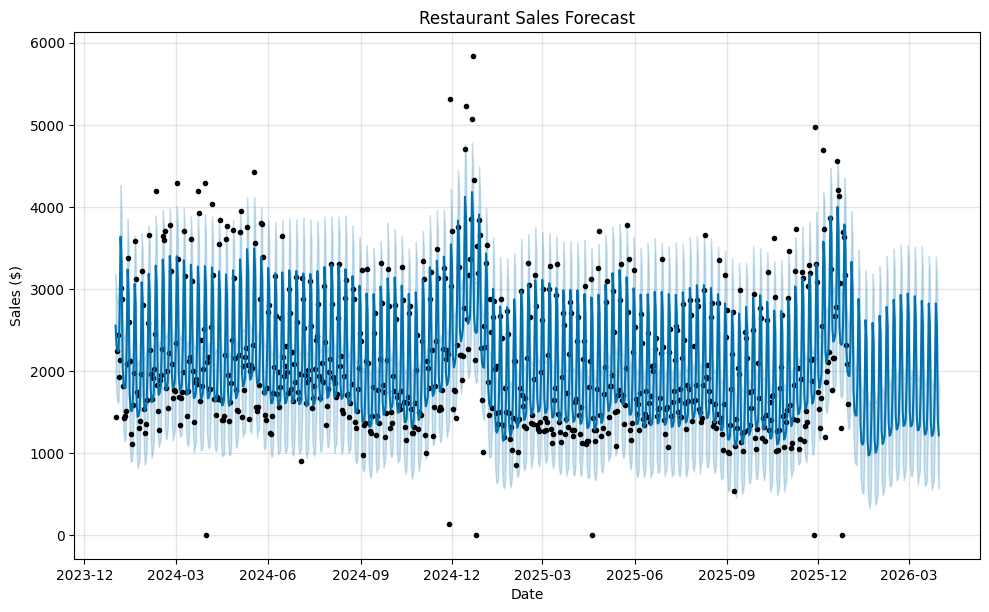

In [22]:
import matplotlib.pyplot as plt

# Plot the forecast
fig1 = model.plot(forecast)
plt.title('Restaurant Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.show()

In [24]:
import numpy as np

# Merge actual values with predicted values on the date column
merged = df_prophet.merge(forecast[['ds', 'yhat']], on='ds')

# Remove rows where actual sales is 0 or null (closed days)
merged = merged[merged['y'] > 0]

# Calculate MAPE
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print(f'MAPE: {mape:.2f}%')
print(f'Forecast Accuracy: {100 - mape:.2f}%')

MAPE: 16.68%
Forecast Accuracy: 83.32%


In [25]:
# Save the chart as a PNG
fig1.savefig('/Users/kevinkim/projects/sales_forecasting/sales_forecast_chart.png')

# Save the forecast data to Excel
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_excel(
    '/Users/kevinkim/projects/sales_forecasting/sales_forecast_output.xlsx', 
    index=False
)

print('Files saved successfully')

Files saved successfully
